Loading data and training models...


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [09:24:41] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



Table II Saved Successfully: 'table_2_model_comparison.csv'
                 Model Accuracy Precision Recall F1-score
0  Logistic Regression     0.32      0.32   0.32     0.30
1        Random Forest     0.33      0.34   0.33     0.33
2              XGBoost     0.34      0.34   0.34     0.34
3                  SVM     0.32      0.32   0.32     0.32
Figure 2 Saved Successfully: 'figure_2_model_ranking.pdf'


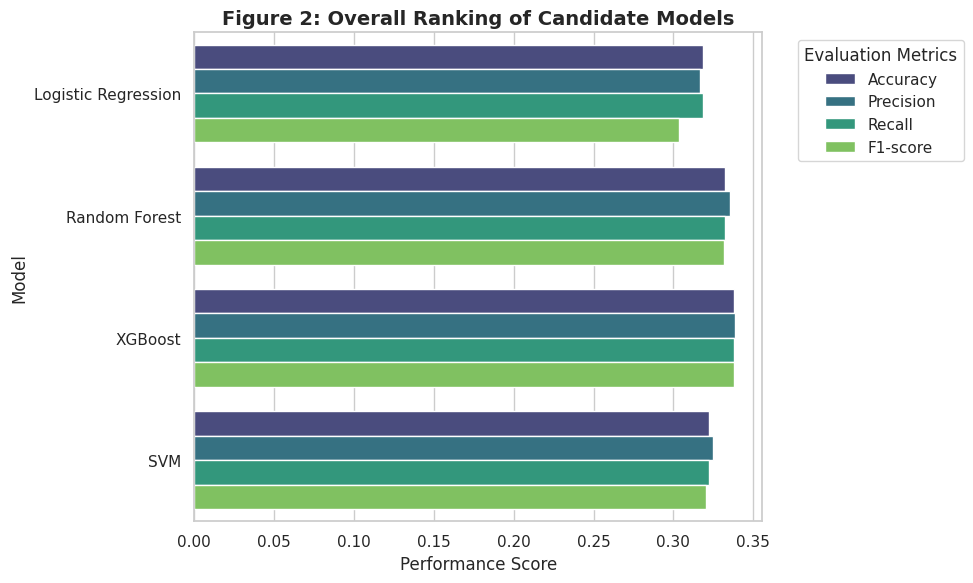

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import os

# --- Configuration ---
# Update this with the actual path to your dataset on Kaggle
DATA_PATH = '/kaggle/input/datasets/imranalishahh/marketing-and-product-performance-dataset/marketing_and_product_performance.csv' 
TARGET_COLUMN = 'Subscription_Tier' # Update to your actual target column name

def load_and_preprocess_data(filepath):
    """Loads and performs basic preprocessing to get data ready for models."""
    df = pd.read_csv(filepath)
    
    # Handle missing values (basic imputation for this step)
    for col in df.select_dtypes(include=['float64', 'int64']).columns:
        df[col] = df[col].fillna(df[col].median())
    for col in df.select_dtypes(include=['object']).columns:
        df[col] = df[col].fillna(df[col].mode()[0])
        
    # Encode categorical variables
    label_encoders = {}
    for column in df.select_dtypes(include=['object']).columns:
        le = LabelEncoder()
        df[column] = le.fit_transform(df[column])
        label_encoders[column] = le
        
    X = df.drop(TARGET_COLUMN, axis=1)
    y = df[TARGET_COLUMN]
    
    # Scale features
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    return train_test_split(X_scaled, y, test_size=0.2, random_state=42)

def train_and_evaluate_models(X_train, X_test, y_train, y_test):
    """Trains candidate models and calculates classification metrics."""
    models = {
        'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
        'Random Forest': RandomForestClassifier(random_state=42),
        'XGBoost': XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42),
        'SVM': SVC(probability=True, random_state=42)
    }
    
    results = []
    
    for name, model in models.items():
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        
        results.append({
            'Model': name,
            'Accuracy': accuracy_score(y_test, y_pred),
            'Precision': precision_score(y_test, y_pred, average='weighted', zero_division=0),
            'Recall': recall_score(y_test, y_pred, average='weighted', zero_division=0),
            'F1-score': f1_score(y_test, y_pred, average='weighted', zero_division=0)
        })
        
    return pd.DataFrame(results)

# --- Execution ---
print("Loading data and training models...")
# NOTE: If your dataset requires specific encoding (like 'latin1'), add it to read_csv
try:
    X_train, X_test, y_train, y_test = load_and_preprocess_data(DATA_PATH)
    
    # Generate Table II
    results_df = train_and_evaluate_models(X_train, X_test, y_train, y_test)
    
    # Format table to match IEEE assignment style (rounding to 2 decimals)
    table_ii = results_df.copy()
    for col in ['Accuracy', 'Precision', 'Recall', 'F1-score']:
        table_ii[col] = table_ii[col].apply(lambda x: f"{x:.2f}")
    
    # Save Table II as CSV
    table_ii.to_csv('table_2_model_comparison.csv', index=False)
    print("\nTable II Saved Successfully: 'table_2_model_comparison.csv'")
    print(table_ii)
    
    # Generate Figure 2: Horizontal Bar Chart
    plt.figure(figsize=(10, 6))
    sns.set_theme(style="whitegrid")
    
    # Melting the dataframe for seaborn barplot
    melted_df = results_df.melt(id_vars='Model', var_name='Metric', value_name='Score')
    
    ax = sns.barplot(x='Score', y='Model', hue='Metric', data=melted_df, palette='viridis')
    plt.title('Figure 2: Overall Ranking of Candidate Models', fontsize=14, fontweight='bold')
    plt.xlabel('Performance Score', fontsize=12)
    plt.ylabel('Model', fontsize=12)
    plt.legend(title='Evaluation Metrics', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    
    # Save Figure 2 as PDF
    plt.savefig('figure_2_model_ranking.pdf', format='pdf', bbox_inches='tight')
    print("Figure 2 Saved Successfully: 'figure_2_model_ranking.pdf'")
    
    plt.show()

except FileNotFoundError:
    print(f"Error: Could not find the dataset at {DATA_PATH}.")
    print("Please update the DATA_PATH variable to point to your Kaggle dataset.")

In [7]:
import pandas as pd
# Use the same path you used in your script
df = pd.read_csv('/kaggle/input/datasets/imranalishahh/marketing-and-product-performance-dataset/marketing_and_product_performance.csv')
print(df.columns)

Index(['Campaign_ID', 'Product_ID', 'Budget', 'Clicks', 'Conversions',
       'Revenue_Generated', 'ROI', 'Customer_ID', 'Subscription_Tier',
       'Subscription_Length', 'Flash_Sale_ID', 'Discount_Level', 'Units_Sold',
       'Bundle_ID', 'Bundle_Price', 'Customer_Satisfaction_Post_Refund',
       'Common_Keywords'],
      dtype='object')


In [9]:
# --- Configuration ---
DATA_PATH = '/kaggle/input/datasets/imranalishahh/marketing-and-product-performance-dataset/marketing_and_product_performance.csv' 
TARGET_COLUMN = 'Subscription_Tier' # Make sure there are no extra spaces